In [1]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import contractions
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob
from nltk.corpus import stopwords, words
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.utils import to_categorical

In [2]:
# Download NLTK 
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')

[nltk_data] Downloading package punkt to C:\Users\T480/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\T480/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to C:\Users\T480/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [3]:
#  Load data komentar
df = pd.read_csv("Data_ScrapYT.csv") 
print(f"Total data awal: {len(df)}")
df

Total data awal: 21040


,Comment
0,Girl with a lot of issues 😂😂😂😂
1,Who gave her this voice?
2,Ayo guys who’s here for a Scaramouche edit
3,Still the best character demo and theme song
4,Yesssss my most beloved character❤❤❤❤❤❤❤❤ I'm ...
...,...
21035,@@smokeygotrobbed4909 agreed plus and also we ...
21036,Can confirm
21037,FOURTH I THINK
21038,Leaving this here for good luck for me and others


### PREPOCESSING TEXT

In [4]:
# Slang dictionary
slang_dict = {
    "u": "you", "ur": "your", "r": "are", "luv": "love", "idk": "i do not know",
    "lol": "laughing out loud", "btw": "by the way", "omg": "oh my god",
    "imho": "in my humble opinion", "b4": "before", "gr8": "great",
    "thx": "thanks", "ty": "thank you", "wtf": "what the fuck",
    "lmao": "laughing my ass off", "tbh": "to be honest", "brb": "be right back"
}

In [5]:
# Stopwords dan stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [6]:
# Deteksi karakter non-latin
def is_weird_text(text):
    non_latin = re.findall(r'[^\x00-\x7F]', text)
    return len(non_latin) / max(len(text), 1) > 0.3

In [7]:
# Fungsi preprocessing lengkap
def clean_comment(text):
    # Case folding
    text = text.lower()

    # Slang normalization
    words = text.split()
    words = [slang_dict[word] if word in slang_dict else word for word in words]
    text = ' '.join(words)

    # Hapus mention, hashtag, RT, URL
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)
    text = re.sub(r'rt[\s]+', '', text)
    text = re.sub(r"http\S+", '', text)

    # Hapus angka, simbol, newline, tanda baca
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r"\s+", " ", text)
    text = text.strip()

    text = contractions.fix(text)  # "im" → "i am", "cant" → "can't"


    # Tokenizing pakai TextBlob
    tokens = TextBlob(text).words

    # Stopword removal & stemming
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

In [8]:
# Preprocessing semua komentar
df['clean_comment'] = df['Comment'].astype(str).apply(clean_comment)

# Filter komentar kosong, aneh, dan bukan English
df = df[df['clean_comment'].str.strip() != '']
df = df[~df['clean_comment'].apply(is_weird_text)].copy()

print(f" Total data bersih: {len(df)}")
df[['Comment', 'clean_comment']].head(10)

 Total data bersih: 20930


,Comment,clean_comment
0,Girl with a lot of issues 😂😂😂😂,girl lot issu
1,Who gave her this voice?,gave voic
2,Ayo guys who’s here for a Scaramouche edit,ayo guy scaramouch edit
3,Still the best character demo and theme song,still best charact demo theme song
4,Yesssss my most beloved character❤❤❤❤❤❤❤❤ I'm ...,yesssss belov charact wait describ much wait
5,Why this Torn to obilivion sounds better!!!!,torn obilivion sound better
6,blessing my eyes again ☝🏻🤓,bless eye
7,THY END IS NOW.,thi end
8,That's like Lunox bg from ML,like lunox bg ml
9,Eyes of eternity,eye etern


In [9]:
# Cek panjangnya
print("Jumlah baris final:", len(df))

Jumlah baris final: 20930


In [10]:
# Reset index (supaya rapi)
df.reset_index(drop=True, inplace=True)

### PELABELAN 

##### VADER (Valence Aware Dictionary for sEntiment Reasoning)

In [11]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sid = SentimentIntensityAnalyzer()

# Fungsi untuk memberi label sentimen
def get_sentiment_vader(text):
    score = sid.polarity_scores(text)
    compound = score['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_vader'] = df['clean_comment'].apply(get_sentiment_vader)
df['sentiment_vader']

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\T480/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


0         neutral
1         neutral
2         neutral
3        positive
4         neutral
           ...   
20925    positive
20926     neutral
20927     neutral
20928    positive
20929     neutral
Name: sentiment_vader, Length: 20930, dtype: object

In [12]:
df['sentiment_vader'].value_counts()

sentiment_vader
positive    8923
neutral     8886
negative    3121
Name: count, dtype: int64

##### TextBlob

In [13]:
from textblob import TextBlob

# Fungsi untuk memberi label sentimen
def get_sentiment_textblob(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'positive'
    elif polarity < 0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_textblob'] = df['clean_comment'].apply(get_sentiment_textblob)
df['sentiment_textblob']

0         neutral
1         neutral
2         neutral
3        positive
4        positive
           ...   
20925     neutral
20926     neutral
20927     neutral
20928    positive
20929    positive
Name: sentiment_textblob, Length: 20930, dtype: object

In [14]:
df['sentiment_textblob'].value_counts()

sentiment_textblob
neutral     11563
positive     7256
negative     2111
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

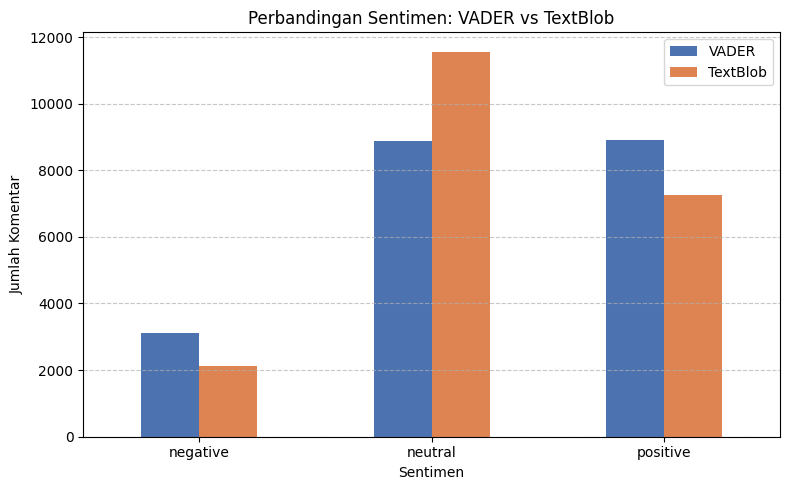

In [15]:
# Hitung distribusi untuk kedua metode
vader_counts = df['sentiment_vader'].value_counts()
textblob_counts = df['sentiment_textblob'].value_counts()

# Gabungkan ke dalam satu DataFrame
compare_df = pd.DataFrame({
    'VADER': vader_counts,
    'TextBlob': textblob_counts
}).fillna(0).astype(int)

# Plot
plt.figure(figsize=(8,5))
compare_df.plot(kind='bar', figsize=(8, 5), color=['#4c72b0', '#dd8452'])

plt.title('Perbandingan Sentimen: VADER vs TextBlob')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Komentar')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### EKSTRAKSI FITUR

##### Bag of Words (BoW)

In [16]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_bow = CountVectorizer()
X_bow = vectorizer_bow.fit_transform(df['clean_comment'])

print(X_bow.shape)

(20930, 10610)


##### TF-IDF (Term Frequency - Inverse Document Frequency)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer()
X_tfidf = vectorizer_tfidf.fit_transform(df['clean_comment'])

print(X_tfidf.shape)

(20930, 10610)


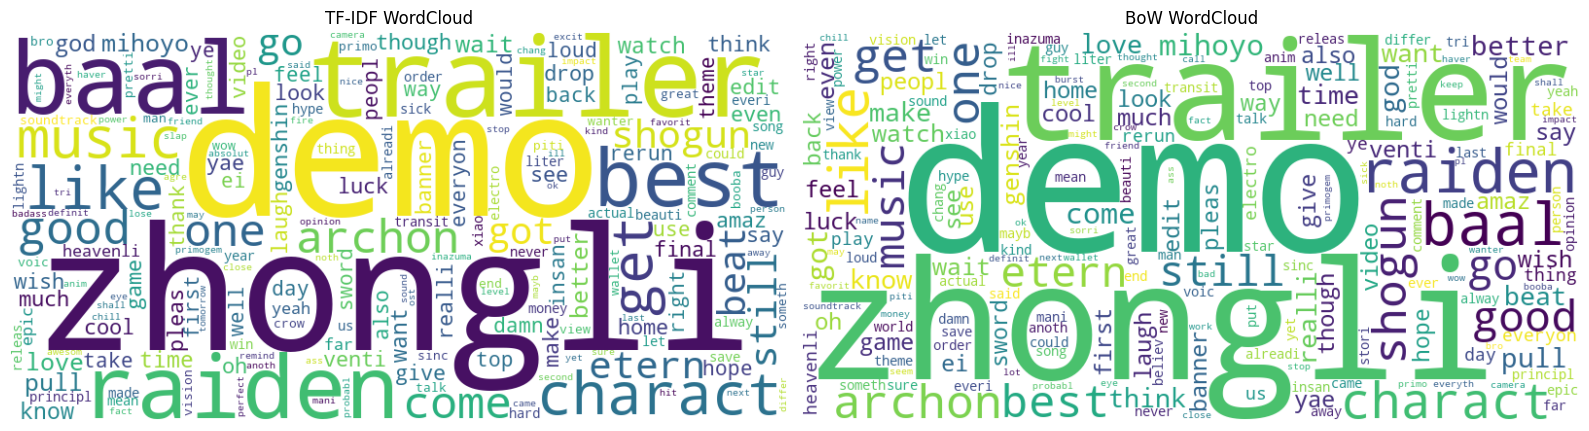

In [18]:
# TF-IDF Word Frequencies
tfidf_words = vectorizer_tfidf.get_feature_names_out()
tfidf_sums = X_tfidf.sum(axis=0).A1  # sum across all documents
tfidf_freq = dict(zip(tfidf_words, tfidf_sums))

# BoW Word Frequencies
bow_words = vectorizer_bow.get_feature_names_out()
bow_sums = X_bow.sum(axis=0).A1
bow_freq = dict(zip(bow_words, bow_sums))

# Buat WordCloud
wordcloud_tfidf = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_freq)
wordcloud_bow = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(bow_freq)

# Tampilkan dalam satu frame
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_tfidf, interpolation='bilinear')
plt.axis('off')
plt.title('TF-IDF WordCloud')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_bow, interpolation='bilinear')
plt.axis('off')
plt.title('BoW WordCloud')

plt.tight_layout()
plt.show()

### MODELLING

Dalam proyek ini, saya menggunakan lima skema pelatihan berbeda dengan memvariasikan algoritma klasifikasi, metode ekstraksi fitur, teknik pelabelan sentimen, dan pembagian data. 

Adapun skema yang digunakan adalah sebagai berikut:

1. LSTM + VADER + 80/20
2. GRU + VADER + 80/20
3. CNN + TextBlob + 70/30
4. SVM + VADER + TF-IDF + 80/20
5. Logistic Regression + TextBlob + BoW + 80/20

Pemilihan kombinasi skema didasarkan pada variasi algoritma, metode ekstraksi fitur, teknik pelabelan, dan pembagian data untuk mengeksplorasi performa model secara menyeluruh. Model deep learning (LSTM, GRU, CNN) tidak menggunakan ekstraksi fitur manual karena mampu mempelajari representasi teks secara otomatis melalui embedding. Sebaliknya, model klasik seperti SVM dan Logistic Regression membutuhkan representasi numerik eksplisit seperti TF-IDF dan BoW. Penggunaan dua metode pelabelan (VADER dan TextBlob) serta variasi pembagian data (80/20 dan 70/30) ditujukan untuk membandingkan hasil klasifikasi di berbagai skenario.

##### LSTM + VADER + 80/20

In [19]:
# Encode label
label_encoder = LabelEncoder()
df['label_encodedvader'] = label_encoder.fit_transform(df['sentiment_vader'])
num_classes = len(label_encoder.classes_)

In [20]:
# Tokenizing & Padding 
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['clean_comment'])
sequences = tokenizer.texts_to_sequences(df['clean_comment'])
padded = pad_sequences(sequences, maxlen=100)

In [21]:
# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(padded, df['label_encodedvader'], test_size=0.2, random_state=42)

In [22]:
# MODEL LSTM
def build_lstm():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128, input_length=100),
        LSTM(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [23]:
# FUNGSI TRAINING 
def train_model_only(model_builder, X_train, y_train, X_test, y_test):
    model = model_builder()
    model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), verbose=1)
    
    return model

In [24]:
# TRAIN MODEL 
modelLSTM = train_model_only(build_lstm, X_train, y_train, X_test, y_test)

c:\Users\T480\Documents\SENTIMENT\fixenv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 46s 150ms/step - accuracy: 0.6360 - loss: 0.7871 - val_accuracy: 0.9245 - val_loss: 0.2650
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 132ms/step - accuracy: 0.9600 - loss: 0.1421 - val_accuracy: 0.9408 - val_loss: 0.1919
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 138ms/step - accuracy: 0.9829 - loss: 0.0644 - val_accuracy: 0.9451 - val_loss: 0.2167
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 32s 123ms/step - accuracy: 0.9845 - loss: 0.0596 - val_accuracy: 0.9472 - val_loss: 0.2219
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 33s 125ms/step - accuracy: 0.9896 - loss: 0.0434 - val_accuracy: 0.9482 - val_loss: 0.2337
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 137ms/step - accuracy: 0.9911 - loss: 0.0351 - val_accuracy: 0.9453 - val_loss: 0.2379
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 38s 143ms/step - accuracy: 0.9912 - loss: 0.0304 - val_accuracy: 0.9443 - val_loss: 0.2521
Epoch 8/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 40s 152ms/step - accuracy: 0.9912 - loss: 0

In [25]:
from sklearn.metrics import accuracy_score

# Fungsi untuk evaluasi model DL (Test Accuracy)
def evaluate_dl_model(model, X_test, y_test, name="Model"):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"{name} - Test Accuracy: {test_acc:.4f}")
    return test_acc

# Ambil nilai akurasi training & validation dari model LSTM
train_acc_lstm = modelLSTM.history.history['accuracy'][-1]
val_acc_lstm = modelLSTM.history.history['val_accuracy'][-1]
test_acc_lstm = evaluate_dl_model(modelLSTM, X_test, y_test, "LSTM")

# Tampilkan hasil
print("Hasil Evaluasi Model LSTM:")
print(f"Train Accuracy     : {train_acc_lstm:.4f}")
print(f"Validation Accuracy: {val_acc_lstm:.4f}")
print(f"Test Accuracy      : {test_acc_lstm:.4f}")


131/131 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step
LSTM - Test Accuracy: 0.9455
Hasil Evaluasi Model LSTM:
Train Accuracy     : 0.9927
Validation Accuracy: 0.9455
Test Accuracy      : 0.9455


##### GRU + VADER + 80/20

In [26]:
# Encode label
label_encoder = LabelEncoder()
df['label_encodedvader'] = label_encoder.fit_transform(df['sentiment_vader'])
num_classes = len(label_encoder.classes_)

In [27]:
# TOKENIZATION 
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_comment'])
sequences = tokenizer.texts_to_sequences(df['clean_comment'])
padded = pad_sequences(sequences, maxlen=100)

In [28]:
# SPLIT DATA 
X_train, X_test, y_train, y_test = train_test_split(
    padded, df['label_encodedvader'], test_size=0.2, random_state=42
)

In [29]:
# MODEL GRU 
def build_gru():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128, input_length=100),
        GRU(128, return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [30]:
# FUNGSI TRAINING
def train_model_only(model_builder, X_train, y_train, X_test, y_test):
    model = model_builder()
    model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), verbose=1)
    return model

In [31]:
# TRAIN MODEL
modelGRU = train_model_only(build_gru, X_train, y_train, X_test, y_test)

Epoch 1/10


c:\Users\T480\Documents\SENTIMENT\fixenv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


262/262 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - accuracy: 0.6609 - loss: 0.7460 - val_accuracy: 0.9348 - val_loss: 0.2174
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 42s 162ms/step - accuracy: 0.9647 - loss: 0.1171 - val_accuracy: 0.9467 - val_loss: 0.1892
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step - accuracy: 0.9827 - loss: 0.0648 - val_accuracy: 0.9496 - val_loss: 0.2167
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 40s 151ms/step - accuracy: 0.9881 - loss: 0.0442 - val_accuracy: 0.9565 - val_loss: 0.2298
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 42s 161ms/step - accuracy: 0.9886 - loss: 0.0421 - val_accuracy: 0.9462 - val_loss: 0.2734
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - accuracy: 0.9913 - loss: 0.0352 - val_accuracy: 0.9515 - val_loss: 0.2955
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step - accuracy: 0.9886 - loss: 0.0388 - val_accuracy: 0.9448 - val_loss: 0.3091
Epoch 8/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 38s 145ms/step - accuracy: 0.9910 - loss: 0.0282 - val

In [32]:
from sklearn.metrics import accuracy_score

# Fungsi untuk evaluasi model DL (Test Accuracy)
def evaluate_dl_model(model, X_test, y_test, name="Model"):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"{name} - Test Accuracy: {test_acc:.4f}")
    return test_acc

# Ambil nilai akurasi training & validation dari model GRU
train_acc_gru = modelGRU.history.history['accuracy'][-1]
val_acc_gru = modelGRU.history.history['val_accuracy'][-1]
test_acc_gru = evaluate_dl_model(modelGRU, X_test, y_test, "GRU")

# Tampilkan hasil
print("Hasil Evaluasi Model GRU:")
print(f"Train Accuracy     : {train_acc_gru:.4f}")
print(f"Validation Accuracy: {val_acc_gru:.4f}")
print(f"Test Accuracy      : {test_acc_gru:.4f}")


131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
GRU - Test Accuracy: 0.9451
Hasil Evaluasi Model GRU:
Train Accuracy     : 0.9914
Validation Accuracy: 0.9451
Test Accuracy      : 0.9451


##### CNN + TextBlob + 70/30

In [33]:
label_encoder = LabelEncoder()
df['label_encoded_blob'] = label_encoder.fit_transform(df['sentiment_textblob'])
num_classesblob = len(label_encoder.classes_)

In [34]:
# TOKENIZATION & PADDING 
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_comment'])
sequences = tokenizer.texts_to_sequences(df['clean_comment'])
padded = pad_sequences(sequences, maxlen=100)

In [35]:
# SPLIT DATA 
X_train, X_test, y_train, y_test = train_test_split(padded, df['label_encoded_blob'], test_size=0.3, random_state=42)

In [36]:
# MODEL CNN
def build_cnn():
    model = Sequential([
        Embedding(input_dim=10000, output_dim=128, input_length=100),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classesblob, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [37]:
# FUNGSI TRAINING 
def train_model_only(model_builder, X_train, y_train, X_test, y_test):
    model = model_builder()
    model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_test, y_test), verbose=1)
    
    return model

In [38]:
# TRAIN MODEL
modelCNN  = train_model_only(build_cnn, X_train, y_train, X_test, y_test)

Epoch 1/10


c:\Users\T480\Documents\SENTIMENT\fixenv\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


229/229 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.7014 - loss: 0.7191 - val_accuracy: 0.9608 - val_loss: 0.1475
Epoch 2/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9681 - loss: 0.1114 - val_accuracy: 0.9782 - val_loss: 0.0861
Epoch 3/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9873 - loss: 0.0519 - val_accuracy: 0.9755 - val_loss: 0.0824
Epoch 4/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9908 - loss: 0.0368 - val_accuracy: 0.9785 - val_loss: 0.0883
Epoch 5/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9937 - loss: 0.0217 - val_accuracy: 0.9767 - val_loss: 0.0894
Epoch 6/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9954 - loss: 0.0155 - val_accuracy: 0.9747 - val_loss: 0.0981
Epoch 7/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9955 - loss: 0.0149 - val_accuracy: 0.9752 - val_loss: 0.1010
Epoch 8/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.9961 - loss: 0.0100 - val_accuracy: 0.97

In [39]:
from sklearn.metrics import accuracy_score

# Fungsi untuk evaluasi model DL (Test Accuracy)
def evaluate_dl_model(model, X_test, y_test, name="Model"):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    test_acc = accuracy_score(y_test, y_pred)
    print(f"{name} - Test Accuracy: {test_acc:.4f}")
    return test_acc

# Ambil nilai akurasi training & validation dari model CNN
train_acc_cnn = modelCNN.history.history['accuracy'][-1]
val_acc_cnn = modelCNN.history.history['val_accuracy'][-1]
test_acc_cnn = evaluate_dl_model(modelCNN, X_test, y_test, "CNN")

# Tampilkan hasil
print("Hasil Evaluasi Model CNN:")
print(f"Train Accuracy     : {train_acc_cnn:.4f}")
print(f"Validation Accuracy: {val_acc_cnn:.4f}")
print(f"Test Accuracy      : {test_acc_cnn:.4f}")

197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
CNN - Test Accuracy: 0.9715
Hasil Evaluasi Model CNN:
Train Accuracy     : 0.9979
Validation Accuracy: 0.9715
Test Accuracy      : 0.9715


##### SVM + VADER + TF-IDF + 80/20

In [40]:
# Encode label
label_encoder = LabelEncoder()
df['label_encodedvader'] = label_encoder.fit_transform(df['sentiment_vader'])
num_classes = len(label_encoder.classes_)

In [41]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, df['label_encodedvader'], test_size=0.2, random_state=42)

In [42]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

#  Split validation dari training data
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [43]:
#  Buat dan latih model SVM
svm_model = LinearSVC()
svm_model.fit(X_train_split, y_train_split)

# Prediksi
y_train_pred = svm_model.predict(X_train_split)
y_val_pred = svm_model.predict(X_val)
y_test_pred = svm_model.predict(X_test)


In [44]:
from sklearn.metrics import accuracy_score

# Evaluasi Akurasi
train_acc_svm = accuracy_score(y_train_split, y_train_pred)
val_acc_svm = accuracy_score(y_val, y_val_pred)
test_acc_svm = accuracy_score(y_test, y_test_pred)

# Tampilkan hasil
print("Hasil Evaluasi Model SVM:")
print(f"Train Accuracy     : {train_acc_svm:.4f}")
print(f"Validation Accuracy: {val_acc_svm:.4f}")
print(f"Test Accuracy      : {test_acc_svm:.4f}")

Hasil Evaluasi Model SVM:
Train Accuracy     : 0.9903
Validation Accuracy: 0.9421
Test Accuracy      : 0.9348


##### Logistic Regression + TextBlob + BoW + 80/20

In [45]:
label_encoder = LabelEncoder()
df['label_encoded_blob'] = label_encoder.fit_transform(df['sentiment_textblob'])
num_classesblob = len(label_encoder.classes_)

In [46]:
# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(X_bow, df['label_encoded_blob'] , test_size=0.2, random_state=42)

# Further Split untuk Validasi
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


In [47]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression Model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train_split, y_train_split)

# Prediksi
y_train_pred = logreg_model.predict(X_train_split)
y_val_pred = logreg_model.predict(X_val)
y_test_pred = logreg_model.predict(X_test)

In [48]:
# Evaluasi Akurasi
train_acc_logreg = accuracy_score(y_train_split, y_train_pred)
val_acc_logreg = accuracy_score(y_val, y_val_pred)
test_acc_logreg = accuracy_score(y_test, y_test_pred)

# Tampilkan Hasil
print("Hasil Evaluasi Logistic Regression:")
print(f"Train Accuracy     : {train_acc_logreg:.4f}")
print(f"Validation Accuracy: {val_acc_logreg:.4f}")
print(f"Test Accuracy      : {test_acc_logreg:.4f}")

Hasil Evaluasi Logistic Regression:
Train Accuracy     : 0.9904
Validation Accuracy: 0.9591
Test Accuracy      : 0.9634


### EVALUASI LENGKAP MODEL

In [49]:
# Data akurasi semua model 
results_df = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'CNN', 'SVM', 'LogReg'],
    'Train Accuracy': [train_acc_lstm, train_acc_gru, train_acc_cnn, train_acc_svm, train_acc_logreg],
    'Validation Accuracy': [val_acc_lstm, val_acc_gru, val_acc_cnn, val_acc_svm, val_acc_logreg],
    'Test Accuracy': [test_acc_lstm, test_acc_gru, test_acc_cnn, test_acc_svm, test_acc_logreg]
})

# Tambahkan kolom indikasi overfitting atau tidak
def get_indication(train, val):
    diff = train - val
    if diff > 0.05:
        return 'Overfit'
    else:
        return 'Good Fit'

results_df['Indikasi'] = results_df.apply(lambda row: get_indication(row['Train Accuracy'], row['Validation Accuracy']), axis=1)

# Tampilkan hasil
print(" Tabel Evaluasi Lengkap:")
print(results_df.round(4))

 Tabel Evaluasi Lengkap:
    Model  Train Accuracy  Validation Accuracy  Test Accuracy  Indikasi
0    LSTM          0.9927               0.9455         0.9455  Good Fit
1     GRU          0.9914               0.9451         0.9451  Good Fit
2     CNN          0.9979               0.9715         0.9715  Good Fit
3     SVM          0.9903               0.9421         0.9348  Good Fit
4  LogReg          0.9904               0.9591         0.9634  Good Fit


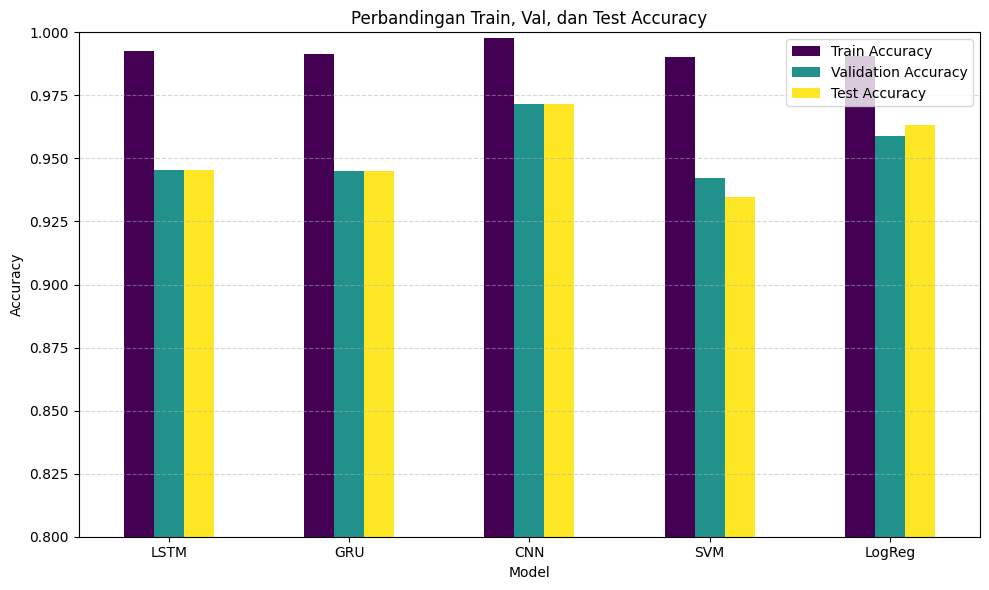

In [50]:
# VISUALISASI dengan NILAI 
ax = results_df.set_index('Model').plot(kind='bar', figsize=(10, 6), ylim=(0.8, 1.0), colormap='viridis')
plt.title("Perbandingan Train, Val, dan Test Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### MENYIMPAN MODEL UNTUK INFERENCE

In [51]:
import os
import joblib
from tensorflow.keras.models import load_model

In [52]:
os.makedirs('models', exist_ok=True)

In [53]:
# Save tokenizer
joblib.dump(tokenizer, 'models/tokenizer.pkl')

# Save vectorizers
joblib.dump(vectorizer_bow, 'models/bow_vectorizer.pkl')
joblib.dump(vectorizer_tfidf, 'models/tfidf_vectorizer.pkl')

# Save deep learning models 
modelLSTM.save('models/lstm_model.keras')  
modelGRU.save('models/gru_model.keras')    
modelCNN.save('models/cnn_model.keras')    

# Save machine learning models
joblib.dump(svm_model, 'models/svm_model.pkl')
joblib.dump(logreg_model, 'models/logreg_model.pkl')


['models/logreg_model.pkl']